# DA5401W — Data Analytics Lab
## Tutorial: Regression - I &nbsp;|&nbsp; Instructor Notebook

| Field | Details |
|---|---|
| **Course** | DA5401W — Data Analytics Lab |
| **Instructor** | Dr. Arun B Ayyar |
| **Tutorial** | Regression - I |
| **Version** | Instructor (with solutions) |

---

### Topics Covered
1. Simple Linear Regression
2. Multiple Linear Regression
3. Polynomial Regression
4. Logarithmic Regression
5. Effect of Parameters on Gradient Descent

> **Instructor Note:** This notebook contains complete solutions, derivations, and explanatory commentary. Please distribute the **Student Notebook** (with blanks) to students before the tutorial session.

---


## Imports and Setup

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Global plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
np.random.seed(42)
print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## 1. Simple Linear Regression

### 1.1 Theory

**Simple Linear Regression** models the relationship between a single independent variable $x$ and a dependent variable $y$ using a straight line:

$$\hat{y} = \beta_0 + \beta_1 x$$

where:
- $\beta_0$ is the **intercept** (value of $\hat{y}$ when $x = 0$),
- $\beta_1$ is the **slope** (change in $\hat{y}$ per unit change in $x$).

The model is fit by minimising the **Residual Sum of Squares (RSS)**:

$$\text{RSS} = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

The **Ordinary Least Squares (OLS)** closed-form solution is:

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}, \qquad \beta_0 = \bar{y} - \beta_1 \bar{x}$$

**Evaluation Metrics:**

| Metric | Formula | Interpretation |
|---|---|---|
| MSE | $\frac{1}{n}\sum(y_i-\hat{y}_i)^2$ | Average squared error; lower is better |
| RMSE | $\sqrt{\text{MSE}}$ | Same units as $y$; lower is better |
| $R^2$ | $1 - \frac{\text{RSS}}{\text{TSS}}$ | Proportion of variance explained; closer to 1 is better |

---


### 1.2 Dataset — Study Hours vs Exam Score

In [6]:
# ── Synthetic dataset: Study hours → Exam score ──────────────────────────────
hours  = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
scores = np.array([35, 42, 57, 61, 72, 78, 83, 88, 92, 97], dtype=float)

df_slr = pd.DataFrame({'Study_Hours': hours, 'Exam_Score': scores})
print(df_slr.to_string(index=False))


 Study_Hours  Exam_Score
         1.0        35.0
         2.0        42.0
         3.0        57.0
         4.0        61.0
         5.0        72.0
         6.0        78.0
         7.0        83.0
         8.0        88.0
         9.0        92.0
        10.0        97.0


### 1.3 OLS — Manual Calculation

In [7]:
# ── OLS closed-form ──────────────────────────────────────────────────────────
x_bar = np.mean(hours)
y_bar = np.mean(scores)

beta_1 = np.sum((hours - x_bar) * (scores - y_bar)) / np.sum((hours - x_bar)**2)
beta_0 = y_bar - beta_1 * x_bar

print(f"Intercept  β₀ = {beta_0:.4f}")
print(f"Slope      β₁ = {beta_1:.4f}")
print(f"Model : ŷ = {beta_0:.2f} + {beta_1:.2f}·x")


Intercept  β₀ = 32.6667
Slope      β₁ = 6.8788
Model : ŷ = 32.67 + 6.88·x


### 1.4 Fitting with scikit-learn and Evaluation

In [8]:
# ── scikit-learn fit ─────────────────────────────────────────────────────────
X_slr = hours.reshape(-1, 1)
model_slr = LinearRegression()
model_slr.fit(X_slr, scores)

y_pred_slr = model_slr.predict(X_slr)

mse  = mean_squared_error(scores, y_pred_slr)
rmse = np.sqrt(mse)
r2   = r2_score(scores, y_pred_slr)

print(f"sklearn  β₀ = {model_slr.intercept_:.4f}")
print(f"sklearn  β₁ = {model_slr.coef_[0]:.4f}")
print(f"\nMSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"R²   = {r2:.4f}")


sklearn  β₀ = 32.6667
sklearn  β₁ = 6.8788

MSE  = 12.6788
RMSE = 3.5607
R²   = 0.9685


### 1.5 Visualisation

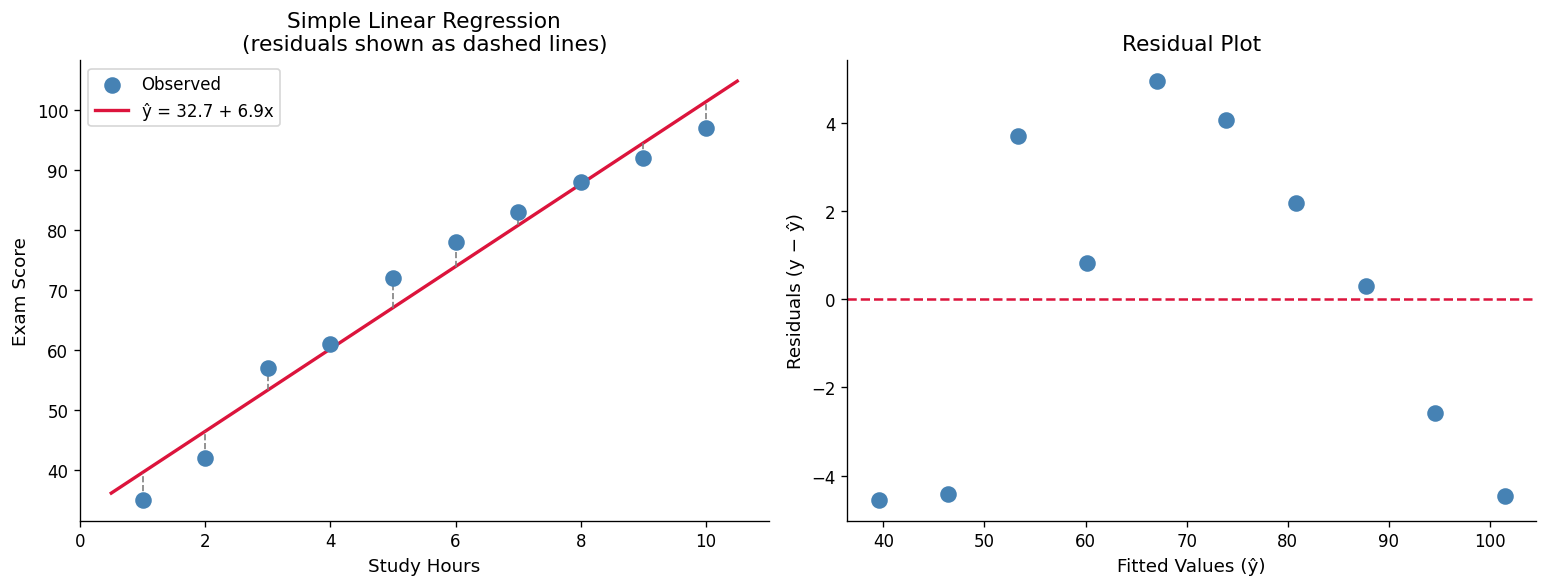

Figure saved as slr_plot.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Scatter + regression line ─────────────────────────────────────────────────
ax = axes[0]
ax.scatter(hours, scores, color='steelblue', s=80, zorder=3, label='Observed')
x_line = np.linspace(hours.min()-0.5, hours.max()+0.5, 200)
ax.plot(x_line, model_slr.predict(x_line.reshape(-1,1)),
        color='crimson', linewidth=2, label=f'ŷ = {beta_0:.1f} + {beta_1:.1f}x')
for xi, yi, yp in zip(hours, scores, y_pred_slr):
    ax.vlines(xi, min(yi, yp), max(yi, yp), colors='grey', linestyles='--', linewidth=1)
ax.set_xlabel('Study Hours')
ax.set_ylabel('Exam Score')
ax.set_title('Simple Linear Regression\n(residuals shown as dashed lines)')
ax.legend()

# ── Residual plot ─────────────────────────────────────────────────────────────
ax2 = axes[1]
residuals = scores - y_pred_slr
ax2.axhline(0, color='crimson', linewidth=1.5, linestyle='--')
ax2.scatter(y_pred_slr, residuals, color='steelblue', s=80)
ax2.set_xlabel('Fitted Values (ŷ)')
ax2.set_ylabel('Residuals (y − ŷ)')
ax2.set_title('Residual Plot')

plt.tight_layout()
plt.savefig('slr_plot.png', bbox_inches='tight')
plt.show()
print("Figure saved as slr_plot.png")


> **Instructor Note:** The residual plot should show residuals scattered randomly around zero with no clear pattern, confirming that a linear model is appropriate for this dataset.

---


---
## 2. Multiple Linear Regression

### 2.1 Theory

**Multiple Linear Regression (MLR)** extends simple linear regression to $p$ predictors:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p$$

In matrix notation with $n$ observations:

$$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\beta}$$

The OLS estimator is:

$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**Assumptions of MLR:**

| Assumption | Description |
|---|---|
| Linearity | $y$ is a linear function of the predictors |
| Independence | Observations are independent of each other |
| Homoscedasticity | Constant variance of residuals |
| Normality | Residuals are normally distributed |
| No multicollinearity | Predictors are not perfectly correlated |

---


### 2.2 Dataset — House Price Prediction

In [ ]:
# ── Synthetic house-price dataset ────────────────────────────────────────────
np.random.seed(0)
n = 120
area       = np.random.uniform(500, 3500, n)          # sq ft
bedrooms   = np.random.randint(1, 6, n).astype(float) # count
age        = np.random.uniform(0, 40, n)              # years

# True relationship (with noise)
price = 50 + 0.12*area + 8*bedrooms - 1.5*age + np.random.normal(0, 15, n)

df_mlr = pd.DataFrame({
    'Area_sqft': area,
    'Bedrooms' : bedrooms,
    'Age_years': age,
    'Price_lakh': price
})

print("Dataset shape:", df_mlr.shape)
print("\nFirst 5 rows:")
print(df_mlr.head().to_string(index=False))
print("\nDescriptive statistics:")
print(df_mlr.describe().round(2).to_string())


### 2.3 Model Fitting

In [ ]:
# ── Train / test split ────────────────────────────────────────────────────────
X_mlr = df_mlr[['Area_sqft', 'Bedrooms', 'Age_years']].values
y_mlr = df_mlr['Price_lakh'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42)

model_mlr = LinearRegression()
model_mlr.fit(X_train, y_train)

print("Coefficients:")
for name, coef in zip(['Area_sqft', 'Bedrooms', 'Age_years'], model_mlr.coef_):
    print(f"  β({name:12s}) = {coef:.4f}")
print(f"  β₀ (intercept)  = {model_mlr.intercept_:.4f}")

y_pred_train = model_mlr.predict(X_train)
y_pred_test  = model_mlr.predict(X_test)

print(f"\nTrain  R² = {r2_score(y_train, y_pred_train):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test   R² = {r2_score(y_test,  y_pred_test ):.4f}  |  RMSE = {np.sqrt(mean_squared_error(y_test,  y_pred_test )):.4f}")


### 2.4 Visualisation — Actual vs Predicted & Feature Importance

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Actual vs Predicted ───────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_test, y_pred_test, color='steelblue', alpha=0.7, s=60, label='Test set')
lims = [min(y_test.min(), y_pred_test.min())-5,
        max(y_test.max(), y_pred_test.max())+5]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (lakh)')
ax.set_ylabel('Predicted Price (lakh)')
ax.set_title('MLR — Actual vs Predicted')
ax.legend()

# ── Feature coefficients ──────────────────────────────────────────────────────
ax2 = axes[1]
features = ['Area_sqft', 'Bedrooms', 'Age_years']
colors   = ['steelblue' if c >= 0 else 'crimson' for c in model_mlr.coef_]
bars = ax2.barh(features, model_mlr.coef_, color=colors, edgecolor='white')
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Coefficient Value')
ax2.set_title('Feature Coefficients')
for bar, val in zip(bars, model_mlr.coef_):
    ax2.text(val + (0.002 if val >= 0 else -0.002),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center',
             ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('mlr_plot.png', bbox_inches='tight')
plt.show()
print("Figure saved as mlr_plot.png")


> **Instructor Note:** Point out that the coefficient for `Age_years` is negative (older houses are cheaper), while `Area_sqft` and `Bedrooms` are positive. Discuss how coefficient magnitude alone is not comparable across features with different scales — standardisation is needed for fair comparison.

---


---
## 3. Polynomial Regression

### 3.1 Theory

**Polynomial Regression** fits a polynomial of degree $d$ to the data:

$$\hat{y} = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_d x^d$$

Although the relationship between $y$ and $x$ is non-linear, the model is still **linear in the parameters** $\boldsymbol{\beta}$, so OLS can be applied after feature engineering (expanding $x$ to $[x, x^2, \ldots, x^d]$).

**Bias-Variance Trade-off:**

| Degree | Bias | Variance | Risk |
|---|---|---|---|
| Too low (e.g., 1) | High | Low | Underfitting |
| Appropriate | Balanced | Balanced | Good generalisation |
| Too high (e.g., 15+) | Low | High | Overfitting |

---


### 3.2 Dataset — Temperature vs Ice Cream Sales

In [ ]:
# ── Non-linear synthetic dataset ─────────────────────────────────────────────
np.random.seed(7)
temp  = np.linspace(5, 40, 60)
sales = -0.5*temp**2 + 25*temp - 100 + np.random.normal(0, 20, 60)

df_poly = pd.DataFrame({'Temperature_C': temp, 'IceCream_Sales': sales})
print("Dataset shape:", df_poly.shape)
print(df_poly.head().to_string(index=False))


### 3.3 Fitting Polynomials of Degrees 1, 2, and 5

In [ ]:
X_poly = temp.reshape(-1, 1)
degrees = [1, 2, 5]
models_poly = {}
metrics_poly = {}

for d in degrees:
    pf = PolynomialFeatures(degree=d, include_bias=False)
    X_d = pf.fit_transform(X_poly)
    m = LinearRegression()
    m.fit(X_d, sales)
    y_hat = m.predict(X_d)
    models_poly[d] = (pf, m)
    metrics_poly[d] = {
        'R2'  : r2_score(sales, y_hat),
        'RMSE': np.sqrt(mean_squared_error(sales, y_hat))
    }

print(f"{'Degree':>8} | {'R²':>8} | {'RMSE':>8}")
print("-" * 32)
for d in degrees:
    print(f"{d:>8} | {metrics_poly[d]['R2']:>8.4f} | {metrics_poly[d]['RMSE']:>8.4f}")


### 3.4 Visualisation — Degree Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors_d = {1: 'crimson', 2: 'seagreen', 5: 'darkorange'}
labels_d = {1: 'Degree 1 (Linear)', 2: 'Degree 2 (Quadratic)', 5: 'Degree 5'}

x_plot = np.linspace(temp.min()-1, temp.max()+1, 300).reshape(-1, 1)

for ax, d in zip(axes, degrees):
    pf, m = models_poly[d]
    y_line = m.predict(pf.transform(x_plot))
    ax.scatter(temp, sales, color='steelblue', s=30, alpha=0.7, label='Data')
    ax.plot(x_plot, y_line, color=colors_d[d], linewidth=2, label=labels_d[d])
    ax.set_xlabel('Temperature (°C)')
    ax.set_title(f'{labels_d[d]}\nR² = {metrics_poly[d]["R2"]:.3f}  RMSE = {metrics_poly[d]["RMSE"]:.2f}')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Ice Cream Sales')
plt.suptitle('Polynomial Regression — Degree Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('poly_plot.png', bbox_inches='tight')
plt.show()
print("Figure saved as poly_plot.png")


### 3.5 Bias-Variance Demonstration — Train vs Test Error

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(X_poly, sales, test_size=0.3, random_state=1)

degree_range = range(1, 12)
train_rmse, test_rmse = [], []

for d in degree_range:
    pf = PolynomialFeatures(degree=d, include_bias=False)
    X_tr_d = pf.fit_transform(X_tr)
    X_te_d = pf.transform(X_te)
    m = LinearRegression()
    m.fit(X_tr_d, y_tr)
    train_rmse.append(np.sqrt(mean_squared_error(y_tr, m.predict(X_tr_d))))
    test_rmse.append(np.sqrt(mean_squared_error(y_te, m.predict(X_te_d))))

plt.figure(figsize=(8, 5))
plt.plot(list(degree_range), train_rmse, 'o-', color='steelblue', label='Train RMSE')
plt.plot(list(degree_range), test_rmse,  's-', color='crimson',   label='Test RMSE')
plt.axvline(2, color='seagreen', linestyle='--', linewidth=1.5, label='Optimal degree = 2')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSE')
plt.title('Bias-Variance Trade-off in Polynomial Regression')
plt.legend()
plt.tight_layout()
plt.savefig('poly_biasvar.png', bbox_inches='tight')
plt.show()
print("Figure saved as poly_biasvar.png")


> **Instructor Note:** Emphasise that while higher-degree polynomials achieve near-zero training error, they perform poorly on unseen data. The sweet spot (degree 2 here) balances bias and variance. This is a key motivation for cross-validation and regularisation.

---


---
## 4. Logarithmic Regression

### 4.1 Theory

**Logarithmic Regression** models a diminishing-returns relationship between $x$ and $y$:

$$\hat{y} = \beta_0 + \beta_1 \ln(x)$$

The key idea is a **variable transformation**: by substituting $z = \ln(x)$, the model becomes linear in $z$, and OLS can be applied directly:

$$\hat{y} = \beta_0 + \beta_1 z, \quad z = \ln(x)$$

**When to use logarithmic regression:**

| Scenario | Indicator |
|---|---|
| Rapid initial growth that levels off | Concave scatter plot |
| Percentage changes matter more than absolute | Economic / biological data |
| Skewed predictor distribution | Long right tail in $x$ |

---


### 4.2 Dataset — Advertising Spend vs Revenue

In [ ]:
# ── Logarithmic synthetic dataset ────────────────────────────────────────────
np.random.seed(3)
ad_spend = np.linspace(1, 200, 80)
revenue  = 20 * np.log(ad_spend) + np.random.normal(0, 5, 80)

df_log = pd.DataFrame({'Ad_Spend_k': ad_spend, 'Revenue_lakh': revenue})
print("Dataset shape:", df_log.shape)
print(df_log.head().to_string(index=False))


### 4.3 Fitting the Logarithmic Model

In [ ]:
# ── Transform x → ln(x) and fit OLS ─────────────────────────────────────────
log_spend = np.log(ad_spend).reshape(-1, 1)

model_log = LinearRegression()
model_log.fit(log_spend, revenue)

y_pred_log = model_log.predict(log_spend)

print(f"β₀ (intercept) = {model_log.intercept_:.4f}")
print(f"β₁ (log coef)  = {model_log.coef_[0]:.4f}")
print(f"\nModel : ŷ = {model_log.intercept_:.2f} + {model_log.coef_[0]:.2f} · ln(x)")
print(f"\nR²   = {r2_score(revenue, y_pred_log):.4f}")
print(f"RMSE = {np.sqrt(mean_squared_error(revenue, y_pred_log)):.4f}")


### 4.4 Visualisation — Original Scale and Log-Transformed Scale

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_line = np.linspace(0.5, 210, 400)

# ── Original scale ────────────────────────────────────────────────────────────
ax = axes[0]
ax.scatter(ad_spend, revenue, color='steelblue', s=40, alpha=0.7, label='Observed')
ax.plot(x_line,
        model_log.intercept_ + model_log.coef_[0]*np.log(x_line),
        color='crimson', linewidth=2,
        label=f'ŷ = {model_log.intercept_:.1f} + {model_log.coef_[0]:.1f}·ln(x)')
ax.set_xlabel('Ad Spend (₹k)')
ax.set_ylabel('Revenue (₹ lakh)')
ax.set_title('Logarithmic Regression (Original Scale)')
ax.legend()

# ── Log-transformed scale ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(np.log(ad_spend), revenue, color='steelblue', s=40, alpha=0.7, label='Observed')
z_line = np.log(x_line)
ax2.plot(z_line,
         model_log.intercept_ + model_log.coef_[0]*z_line,
         color='crimson', linewidth=2, label='OLS fit on ln(x)')
ax2.set_xlabel('ln(Ad Spend)')
ax2.set_ylabel('Revenue (₹ lakh)')
ax2.set_title('After Log Transformation (Linearised)')
ax2.legend()

plt.tight_layout()
plt.savefig('log_plot.png', bbox_inches='tight')
plt.show()
print("Figure saved as log_plot.png")


> **Instructor Note:** The left panel shows the characteristic concave curve of logarithmic growth. The right panel shows that after the log transformation the relationship becomes perfectly linear, justifying the use of OLS.

---


---
## 5. Effect of Parameters on Gradient Descent

### 5.1 Theory

**Gradient Descent** is an iterative optimisation algorithm that minimises a cost function $J(\boldsymbol{\theta})$ by updating parameters in the direction of the negative gradient:

$$\theta_j \leftarrow \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

For **Mean Squared Error** with a single parameter $\theta$ (slope only, for simplicity):

$$J(\theta) = \frac{1}{2n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

**Key hyperparameters and their effects:**

| Parameter | Effect if Too Small | Effect if Too Large |
|---|---|---|
| Learning rate $\alpha$ | Slow convergence; many iterations needed | Overshooting; may diverge |
| Initial $\theta_0$ | May converge to local minimum (non-convex) | Same risk; affects path |
| Batch size | Noisy updates (SGD) | Smooth but slow per epoch (batch GD) |

---


### 5.2 Gradient Descent Implementation from Scratch

In [ ]:
# ── Simple 1-D dataset for gradient descent illustration ─────────────────────
np.random.seed(10)
x_gd = np.linspace(0, 10, 50)
y_gd = 3.5 * x_gd + 7 + np.random.normal(0, 4, 50)

def compute_cost(theta0, theta1, x, y):
    n = len(y)
    y_hat = theta0 + theta1 * x
    return (1 / (2*n)) * np.sum((y_hat - y)**2)

def gradient_descent(x, y, theta0_init, theta1_init, alpha, n_iter):
    n = len(y)
    theta0, theta1 = theta0_init, theta1_init
    cost_history = []
    theta0_hist, theta1_hist = [theta0], [theta1]

    for _ in range(n_iter):
        y_hat = theta0 + theta1 * x
        grad0 = (1/n) * np.sum(y_hat - y)
        grad1 = (1/n) * np.sum((y_hat - y) * x)
        theta0 -= alpha * grad0
        theta1 -= alpha * grad1
        cost_history.append(compute_cost(theta0, theta1, x, y))
        theta0_hist.append(theta0)
        theta1_hist.append(theta1)

    return theta0, theta1, cost_history, theta0_hist, theta1_hist

# Reference run
t0, t1, cost_hist, _, _ = gradient_descent(x_gd, y_gd, 0, 0, alpha=0.01, n_iter=500)
print(f"Converged: θ₀ = {t0:.4f}, θ₁ = {t1:.4f}")
print(f"Final cost J = {cost_hist[-1]:.4f}")


### 5.3 Effect of Learning Rate $\alpha$

In [ ]:
alphas   = [0.001, 0.01, 0.05, 0.2]
n_iter   = 300
colors_a = ['steelblue', 'seagreen', 'darkorange', 'crimson']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax_cost = axes[0]
ax_path = axes[1]

for alpha, col in zip(alphas, colors_a):
    t0, t1, ch, t0h, t1h = gradient_descent(x_gd, y_gd, 0, 0, alpha, n_iter)
    label = f'α = {alpha}'
    if not any(np.isnan(ch)):
        ax_cost.plot(ch, color=col, linewidth=1.8, label=label)
        ax_path.plot(t0h, t1h, 'o-', color=col, markersize=2, linewidth=1, label=label)
    else:
        ax_cost.plot([], [], color=col, label=label + ' (diverged)')

ax_cost.set_xlabel('Iteration')
ax_cost.set_ylabel('Cost J(θ)')
ax_cost.set_title('Cost vs Iterations for Different Learning Rates')
ax_cost.legend()
ax_cost.set_ylim(0, 500)

ax_path.set_xlabel('θ₀ (intercept)')
ax_path.set_ylabel('θ₁ (slope)')
ax_path.set_title('Parameter Trajectory During Gradient Descent')
ax_path.legend()

plt.tight_layout()
plt.savefig('gd_lr.png', bbox_inches='tight')
plt.show()
print("Figure saved as gd_lr.png")


### 5.4 Effect of Number of Iterations

In [ ]:
iter_list = [10, 50, 100, 500]
alpha_fixed = 0.01

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

x_line_gd = np.linspace(x_gd.min(), x_gd.max(), 200)

for ax, n_it in zip(axes.flatten(), iter_list):
    t0, t1, _, _, _ = gradient_descent(x_gd, y_gd, 0, 0, alpha_fixed, n_it)
    ax.scatter(x_gd, y_gd, color='steelblue', s=25, alpha=0.6, label='Data')
    ax.plot(x_line_gd, t0 + t1*x_line_gd, color='crimson', linewidth=2,
            label=f'θ₀={t0:.2f}, θ₁={t1:.2f}')
    ax.set_title(f'Iterations = {n_it}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle(f'Effect of Number of Iterations (α = {alpha_fixed})', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('gd_iters.png', bbox_inches='tight')
plt.show()
print("Figure saved as gd_iters.png")


### 5.5 Cost Surface and Gradient Descent Path

In [ ]:
# ── Compute cost surface ──────────────────────────────────────────────────────
theta0_vals = np.linspace(-10, 20, 100)
theta1_vals = np.linspace(-1, 8, 100)
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)
J_surface = np.array([[compute_cost(t0, t1, x_gd, y_gd)
                        for t0 in theta0_vals]
                       for t1 in theta1_vals])

_, _, _, t0h, t1h = gradient_descent(x_gd, y_gd, -5, 0, alpha=0.01, n_iter=300)

fig = plt.figure(figsize=(14, 5))

# ── Contour plot ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(121)
cp = ax1.contourf(T0, T1, J_surface, levels=40, cmap='viridis')
plt.colorbar(cp, ax=ax1, label='Cost J(θ)')
ax1.plot(t0h, t1h, 'w-o', markersize=3, linewidth=1.5, label='GD path')
ax1.plot(t0h[0], t1h[0], 'rs', markersize=8, label='Start')
ax1.plot(t0h[-1], t1h[-1], 'r*', markersize=12, label='End')
ax1.set_xlabel('θ₀')
ax1.set_ylabel('θ₁')
ax1.set_title('Cost Surface Contour with GD Path')
ax1.legend(fontsize=8)

# ── 3-D surface ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(T0, T1, J_surface, cmap='viridis', alpha=0.7)
ax2.set_xlabel('θ₀')
ax2.set_ylabel('θ₁')
ax2.set_zlabel('J(θ)')
ax2.set_title('3D Cost Surface')

plt.tight_layout()
plt.savefig('gd_surface.png', bbox_inches='tight')
plt.show()
print("Figure saved as gd_surface.png")


### 5.6 Effect of Initialisation

In [ ]:
inits = [(-8, 0), (0, 0), (15, 6), (5, -0.5)]
init_colors = ['crimson', 'steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 6))
cp = ax.contourf(T0, T1, J_surface, levels=40, cmap='viridis', alpha=0.85)
plt.colorbar(cp, ax=ax, label='Cost J(θ)')

for (i0, i1), col in zip(inits, init_colors):
    _, _, _, t0h, t1h = gradient_descent(x_gd, y_gd, i0, i1, alpha=0.01, n_iter=300)
    ax.plot(t0h, t1h, '-o', color=col, markersize=2, linewidth=1.5,
            label=f'Init (θ₀={i0}, θ₁={i1})')
    ax.plot(t0h[0], t1h[0], 's', color=col, markersize=8)
    ax.plot(t0h[-1], t1h[-1], '*', color=col, markersize=12)

ax.set_xlabel('θ₀')
ax.set_ylabel('θ₁')
ax.set_title('Effect of Initialisation on Gradient Descent Path')
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('gd_init.png', bbox_inches='tight')
plt.show()
print("Figure saved as gd_init.png")


> **Instructor Note:** For a convex cost function (as in linear regression), all initialisations converge to the same global minimum. This is an important distinction from non-convex losses (e.g., in neural networks) where initialisation can matter significantly.

---


---
## Summary

| Topic | Key Formula | When to Use |
|---|---|---|
| Simple Linear Regression | $\hat{y} = \beta_0 + \beta_1 x$ | One predictor, linear relationship |
| Multiple Linear Regression | $\hat{y} = \beta_0 + \sum_j \beta_j x_j$ | Multiple predictors, linear relationship |
| Polynomial Regression | $\hat{y} = \sum_{k=0}^{d} \beta_k x^k$ | Non-linear, curved relationship |
| Logarithmic Regression | $\hat{y} = \beta_0 + \beta_1 \ln(x)$ | Diminishing returns, concave growth |
| Gradient Descent | $\theta \leftarrow \theta - \alpha \nabla J$ | Iterative optimisation for large datasets |

---
*DA5401W — Data Analytics Lab | Instructor: Dr. Arun B Ayyar | Tutorial: Regression - I*
